In [3]:
import numpy as np
import scipy
from Scripts.Optimization.optimization import Optimizer
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.material_properties import Materials


In [4]:
opt = Optimizer()
opt.independent_properties_calc()
print(opt.mission_profile.duration)
opt.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt.design_variables_initial_guess = {
    "arm_diameter": 50,
    "arm_thickness": 2.5,
    "strut_diameter": 40.0,
    "strut_thickness": 0.254,
    "strut_distance": 475,
    "hub_radius": 300,
    "hub_flange_thickness": 3,
    "hub_web_thickness": 2
}

opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
opt.constraints_constants["allowable_deflection"] = 10

res = opt.run_opt()

x = np.array(res.x)
x_expanded = list(opt.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt.test_results(x)


dv_keys = list(opt.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"res: {res.fun}")


print("OPT_OUTPUT")
opt.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

640
Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 1.8409232357368561
   strut_diameter: 50.0
   strut_thickness: 0.32763714701767177
   strut_distance: 475.1250103008326
   hub_radius: 309.169505059346
   hub_flange_thickness: 1.203243266738808
   hub_web_thickness: 0.7262476787677613
constraints
   deflection: 1.000000225923459
   stress: 0.25816316335569334
   displacement amplitude: 0.999999467769618
   energy: 0.9372103729223225
   damage: 0.0
res: 2.821637232398636
OPT_OUTPUT
Initial guess opt actual:
[5.00000000e+01 1.84092324e+00 5.00000000e+01 3.27637147e-01
 4.75125010e+02 3.09169505e+02 1.20324327e+00 7.26247679e-01]


In [5]:
initial_design_vars = opt.design_variables_initial_guess
active_constraints = opt.active_constraints
constraints_res, labels = opt.constraint_calculations(initial_design_vars, active_constraints)

print("===== Initial Guess =====")
print("constraints")
for i in range(len(constraints_res)):
    print(f"   {labels[i]}: {constraints_res[i]}")



===== Initial Guess =====
constraints
   deflection: 0.6623824728575725
   stress: 0.12278745678867518
   displacement amplitude: 0.8287849109519962


In [6]:
import os
import pandas as pd

table_path = "Tables/Sensitivity_Testing_Ver_2.csv"

for i in range(8):
    case_title = "Case " + str(i)
    x2 = [
        ((x[0] - 0.001 * x[0])) if i in (0, 1, 2, 3) else (x[0] + 0.001 * x[0]),
        ((x[1] - 0.001 * x[1])) if i in (0, 1, 4, 5) else (x[1] + 0.001 * x[1]),
        ((x[2] - 0.001 * x[2])) if i in (0, 3, 5, 7) else (x[2] + 0.001 * x[2])
    ]
    print(x2)
    cons_res_opt, cons_labels_opt = opt.test_results(x2)
    mass = opt.mass(opt.reform_dvs(x2))

    data = {}
    data.update(opt.reform_dvs(x2))
    opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
    data.update(opt_dictionary)
    data.update({"mass": mass * 1000})

    print(data)

    # Ensure directory exists
    os.makedirs(os.path.dirname(table_path), exist_ok=True)

    new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

    if os.path.exists(table_path):
        try:
            df_existing = pd.read_csv(table_path, index_col=0)
        except Exception:
            df_existing = pd.DataFrame()

        if df_existing.empty:
            df = new_col_df
        else:
            for idx in new_col_df.index:
                if idx not in df_existing.index:
                    df_existing.loc[idx] = pd.NA
            df_existing[case_title] = new_col_df[case_title]
            df = df_existing
    else:
        df = new_col_df

    df.to_csv(table_path, index=True)


[np.float64(49.95), np.float64(1.7894881138420022), np.float64(8.991)]


C:\Desktop\UAV_Mission\Scripts\Finite_Elements\Beam_FEA_System\beam_type.py:34: RuntimeWarning: invalid value encountered in scalar divide
  self.g_y = eik_y/ga
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\Beam_FEA_System\beam_type.py:35: RuntimeWarning: invalid value encountered in scalar divide
  self.g_z = eik_z/ga
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\cross_section_properties.py:140: RuntimeWarning: invalid value encountered in scalar divide
  kx = math.sqrt(J_polar / area)
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\cross_section_properties.py:141: RuntimeWarning: invalid value encountered in scalar divide
  ky = math.sqrt(Iy / area)
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\cross_section_properties.py:142: RuntimeWarning: invalid value encountered in scalar divide
  kz = math.sqrt(Iz / area)
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\cross_section_properties.py:145: RuntimeWarning: invalid value encountered in scalar divide
  Sy = Iy / (b / 2.0)
C:\Desktop\

ZeroDivisionError: float division by zero

In [13]:
import os
import pandas as pd
table_path = "Tables/Sensitivity_Testing_Ver_2.csv"
case_title = "Optimal Point"

mass = opt.mass(opt.reform_dvs(x))

data = {}
data.update(opt.reform_dvs(x))
opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
data.update(opt_dictionary)
data.update({"mass":mass * 1000})

print(data)

# Ensure directory exists
os.makedirs(os.path.dirname(table_path), exist_ok=True)

new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

if os.path.exists(table_path):
    try:
        df_existing = pd.read_csv(table_path, index_col=0)
    except Exception:
        df_existing = pd.DataFrame()

    if df_existing.empty:
        df = new_col_df
    else:
        for idx in new_col_df.index:
            if idx not in df_existing.index:
                df_existing.loc[idx] = pd.NA
        df_existing[case_title] = new_col_df[case_title]
        df = df_existing
else:
    df = new_col_df

df.to_csv(table_path, index=True) 


{'arm_diameter': np.float64(49.999999998552674), 'arm_thickness': np.float64(1.0514423971590228), 'strut_diameter': np.float64(49.999979531336535), 'strut_thickness': np.float64(0.25400000000000006), 'strut_distance': np.float64(483.21866260289374), 'hub_radius': np.float64(483.184295396726), 'hub_flange_thickness': np.float64(0.7022584492033298), 'hub_web_thickness': np.float64(2.539710419670471), 'deflection': np.float64(0.9999999999721352), 'stress': np.float64(0.22868755360974904), 'displacement amplitude': np.float64(0.08055590863663885), 'energy': np.float64(0.9801213409505845), 'damage': np.float64(0.0), 'mass': np.float64(3.6874872700024595)}


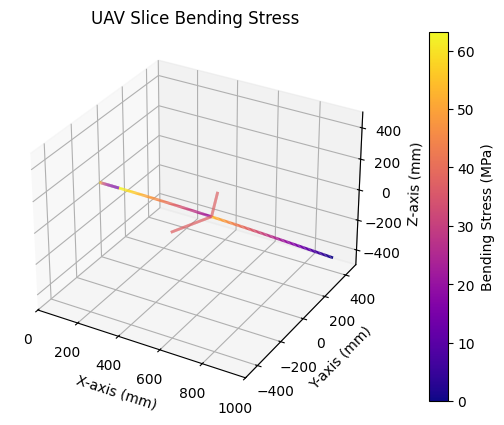

In [5]:
from Scripts.visualization import drone_geometry_stress

drone_geometry_stress(opt.fea, 1, 100)

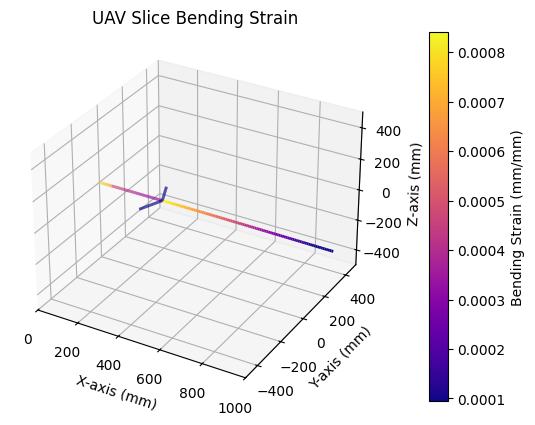

In [3]:
from Scripts.visualization import drone_geometry_strain

drone_geometry_strain(opt.fea, 1, 100)

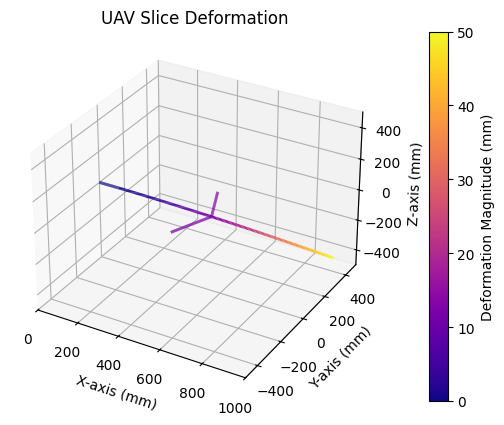

In [7]:
from Scripts.visualization import drone_geometry_deformation

drone_geometry_deformation(opt.fea, 1, 100)

In [8]:
import Scripts.unit_conversions as uc
opt.fea.beam_system.solve_natural_frequencies()
print(f"First Nf: {opt.fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {opt.fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")

First Nf: 24.247720460214193 Hz
Second Nf: 55.42780364276522 Hz


56.1363162501806
52.27863351822437


{'arm_diameter': 50.0, 'arm_thickness': 0.30225113750976107, 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.5), 'strut_distance': np.float64(600.0), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


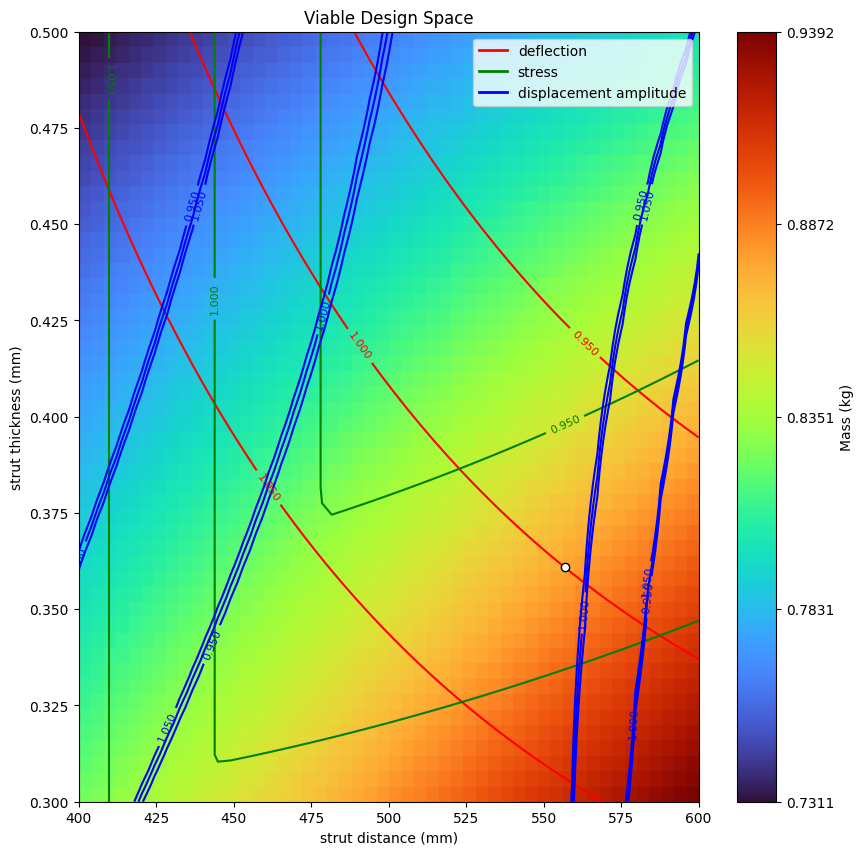

In [10]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 50, design_variables, (400, 600), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.5), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.5), 'strut_distance': 556.7873877215278, 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


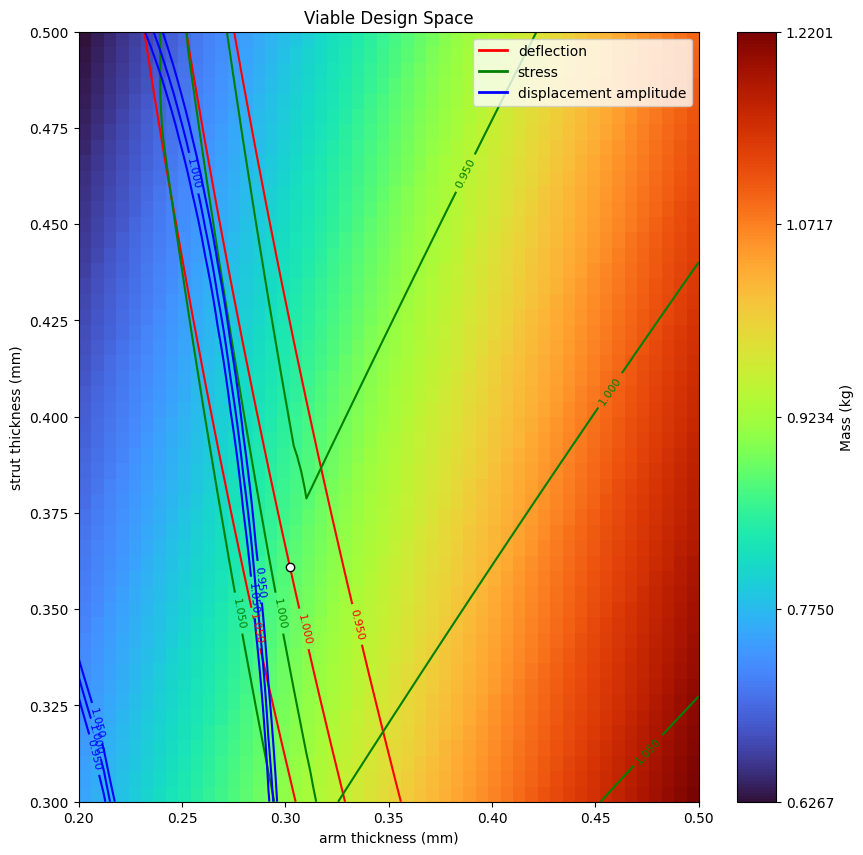

In [11]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 50, design_variables, (0.2, 0.5), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': 0.30225113750976107, 'strut_diameter': 50.0, 'strut_thickness': np.float64(3.175), 'strut_distance': np.float64(1127.3), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


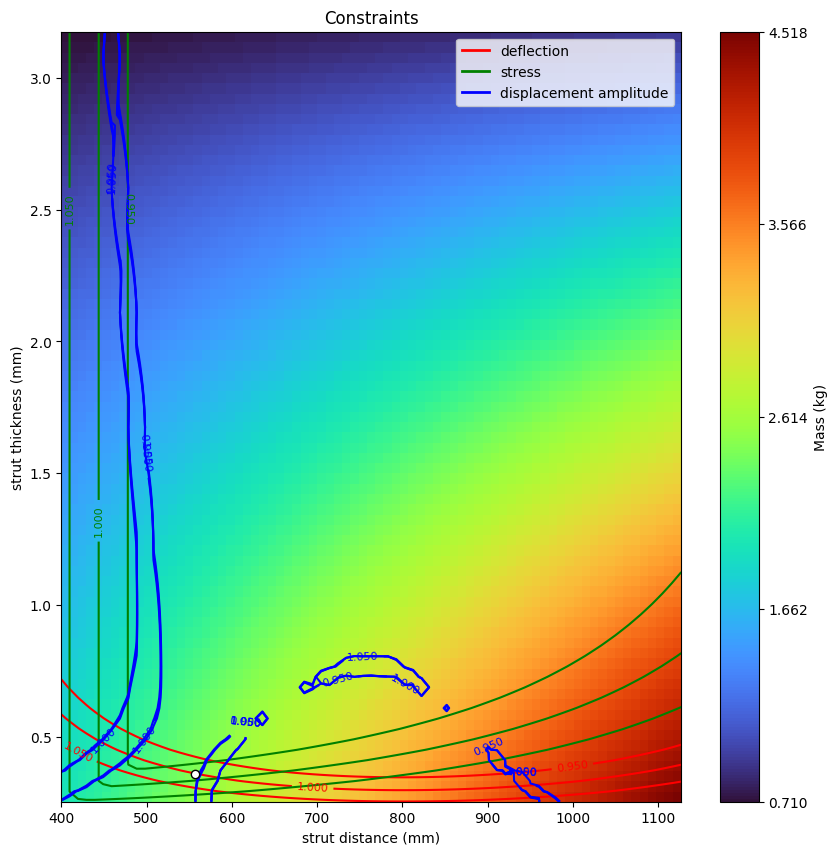

In [12]:
# zoomed out
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 75, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

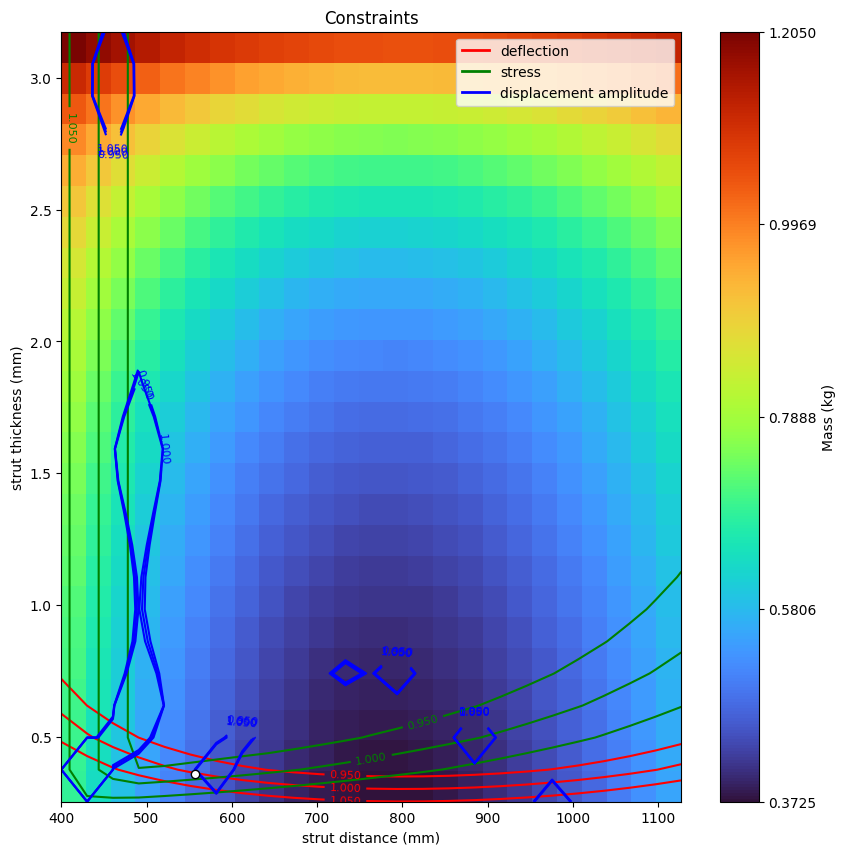

In [13]:
# TEST
from Scripts.visualization import design_space_test_cons
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_test_cons(opt, "strut_distance", "strut_thickness", 25, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

In [14]:
design_variables = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": 1.75,
    "strut_distance": 1100,
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}
constraints_res, labels = opt.constraint_calculations(design_variables, active_constraints, True)
for i in range(len(constraints_res)):
    print(f"{labels[i]}: {constraints_res[i]}")

deflection: 0.6149177853712312
stress: 0.8899480537968972
displacement amplitude: 0.02880127280218797


{'arm_diameter': 50.0, 'arm_thickness': np.float64(3.175), 'strut_diameter': 50.0, 'strut_thickness': np.float64(3.175), 'strut_distance': 556.7873877215278, 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


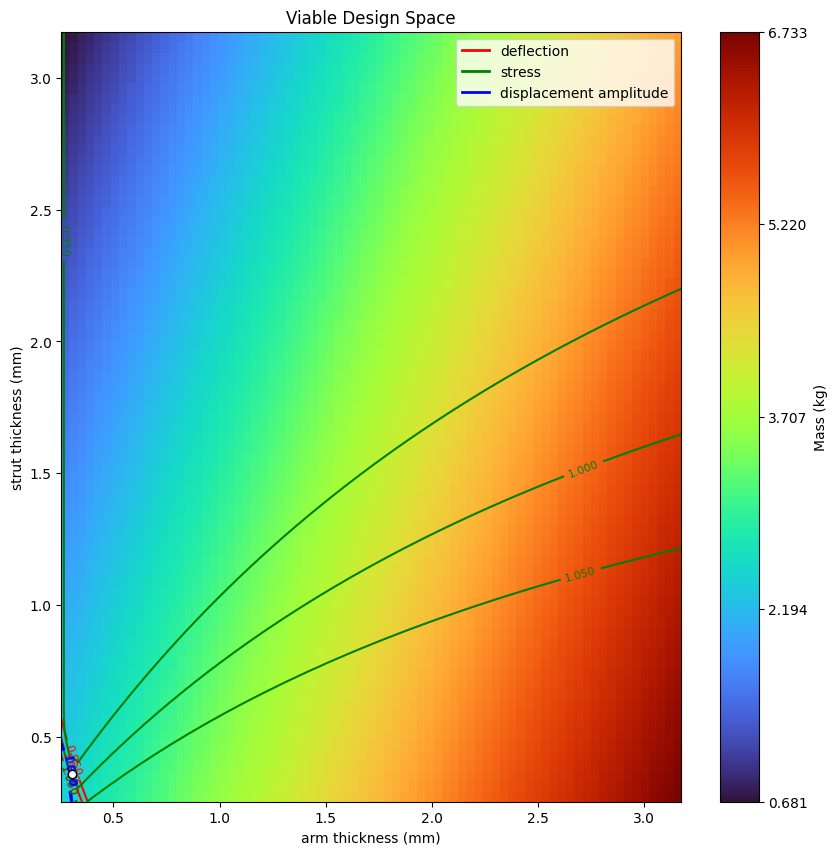

In [15]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 75, design_variables, None, None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

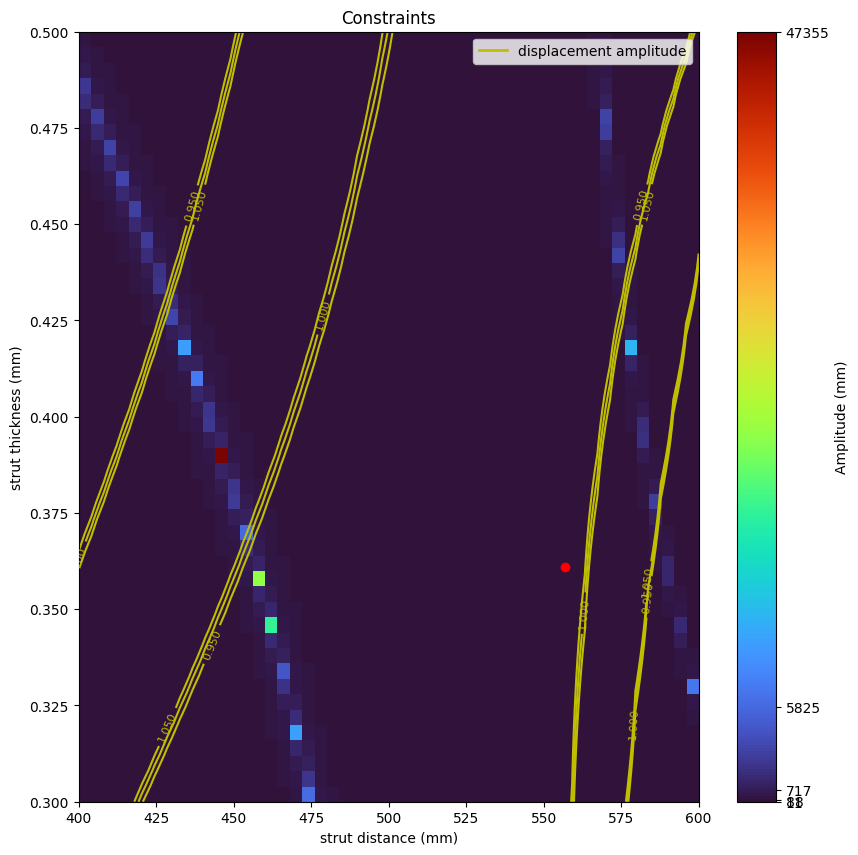

In [16]:
# plot the space
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 50, design_variables,(400,600),(0.3,0.5),{
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

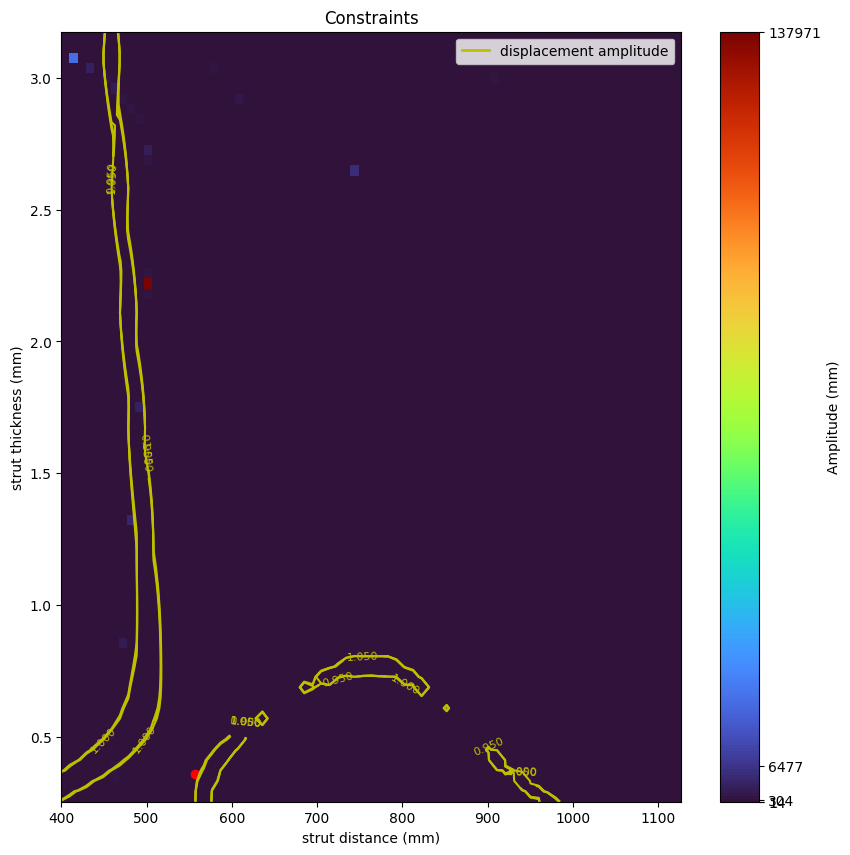

In [17]:

# zoomed out
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 75, design_variables,None,None, {
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

Initial guess 1 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 25,
    "strut_diameter": 50.0,
    "strut_thickness": 25,
    "strut_distance": 510,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31612437848973063
   strut_diameter: 50.0
   strut_thickness: 0.3602027837054039
   strut_distance: 509.98696996881597
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999970214
   stress: 0.955560709497491
   frequency: 0.26171190065852373
   energy: 0.326065371252493
   damage: 0.0
mass w/ payload: 0.8265042304244963 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16124378e-01 3.60202784e-01 5.09986970e+02]

Initial guess 2 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 1,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}


===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3022755041161241
   strut_diameter: 50.0
   strut_thickness: 0.3608985852993385
   strut_distance: 556.6928996805128
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999539
   stress: 0.9780731466461088
   frequency: 0.2914667465901592
   energy: 0.3260612237046038
   damage: 0.0
mass w/ payload: 0.8250114520506969 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275504e-01 3.60898585e-01 5.56692900e+02]

Inital Guess 3 tol=1e-18

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30227574532156787
   strut_diameter: 50.0
   strut_thickness: 0.3608980022929013
   strut_distance: 556.6928997650245
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.999999999999994
   stress: 0.9780730549779
   frequency: 0.29146623894235507
   energy: 0.32606122370460633
   damage: 0.0
mass w/ payload: 0.8250114520506582 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275745e-01 3.60898002e-01 5.56692900e+02]

Initial Guess 4 tol=1e-18

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31654251873360006
   strut_diameter: 50.0
   strut_thickness: 0.48657929350939877
   strut_distance: 412.17184660354866
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000000000013
   stress: 1.0000000000000078
   frequency: 1.0000000000001152
   energy: 0.3261353943704316
   damage: 0.0
mass w/ payload: 0.8461615400019418 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16542519e-01 4.86579294e-01 4.12171847e+02]

In [3]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc
uav_geo = opt.drone_geometry
uav_fea = fea.DroneFEA(uav_geo)
uav_fea.create_drone_nodes()
uav_fea.create_drone_beams()
# uav_fea.boundary_conditions()
uav_fea.solve_fea()
uav_fea.beam_system.solve_natural_frequencies()
np.set_printoptions(precision=3,suppress=True)
print(f"First Nf: {uav_fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {uav_fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")
print(f"Third Nf: {uav_fea.beam_system.natural_frequencies[2] * uc.rad_per_s_to_Hz} Hz")
print(f"Fourth Nf: {uav_fea.beam_system.natural_frequencies[3] * uc.rad_per_s_to_Hz} Hz")
print(f"Nf: {uav_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz} Hz")

First Nf: 0.0 Hz
Second Nf: 0.0 Hz
Third Nf: 0.0 Hz
Fourth Nf: 0.0 Hz
Nf: [     0.         0.         0.         0.         0.013      0.013
     22.425     24.5       24.5       28.215     28.215     30.847
     30.847     31.633     33.32      33.32      33.32      33.321
     33.321     38.051     38.051     38.456     38.456     39.183
     39.183     39.34      39.927     61.583     62.717     62.717
     65.401     65.401     67.863     67.863     68.838     83.071
     83.284     83.284     90.682     91.211     91.211     92.685
     92.685     94.596     94.596     95.296    118.116    118.135
    118.135    118.19     118.19     118.258    118.258    118.292
    141.981    141.981    142.073    142.073    142.106    161.958
    161.958    168.689    168.689    168.691    168.691    168.691
    168.691    168.691    168.691    174.713    179.287    179.287
    185.577    185.577    186.811    217.379    217.472    217.472
    245.711    245.711    245.795    245.795    245.828

In [4]:
import matplotlib.pyplot as plt
import Scripts.unit_conversions as uc

drone_power = opt.drone_power_module
m1 = opt.mission_profile

power_list = drone_power.timesteps.copy()
thrust_list = drone_power.timesteps.copy()
osc_list = drone_power.timesteps.copy()
time_list = drone_power.timesteps.copy()
drone_mass = opt.drone_mass
surface_area = opt.surface_area
for i, t in enumerate(time_list):
    power_list[i] = drone_power.power_at_time(t)
    thrust_list[i] = opt.total_force_y(t, drone_mass, surface_area)
    osc_list[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)


print(opt.mission_profile)
# Power vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Power vs Time")
plt.plot(time_list, power_list / 1000)
plt.grid()
plt.ylabel("W")
plt.xlabel("s")
plt.tight_layout()
plt.show()

AttributeError: 'Optimizer' object has no attribute 'surface_area'

<llm-snippet-file>Optimization_Experiments_1percent.ipynb</llm-snippet-file>


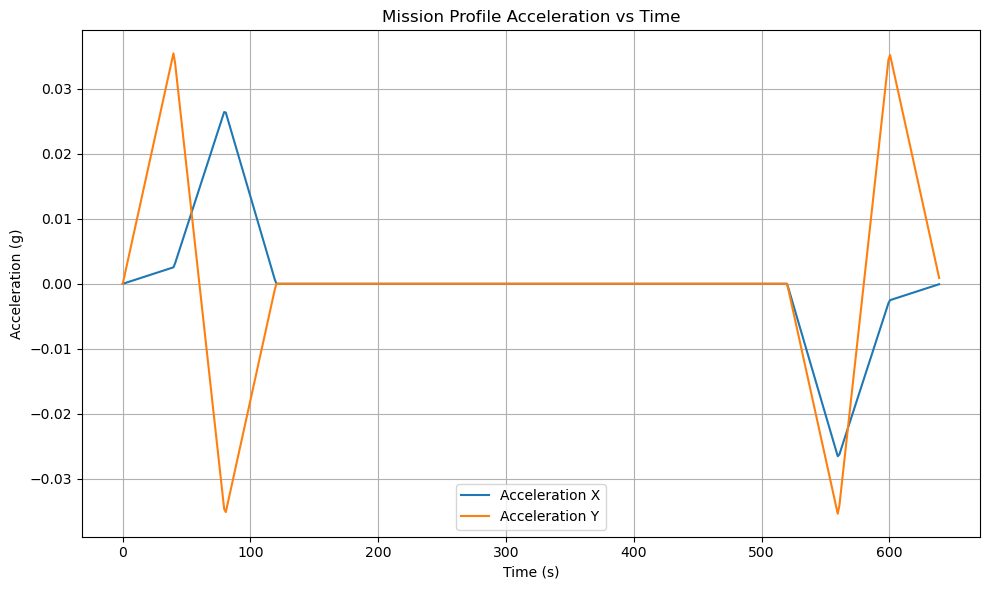

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Generate time range for the mission duration
duration = opt.mission_profile.duration
t_range = np.linspace(0, duration - 1, 500)

accel_x = np.zeros(len(t_range))
accel_y = np.zeros(len(t_range))

# Gravity constant in mm/s² (assuming mm is the unit based on the original label)
g = 9806.65

# Solve kinematics for each time step
for i, t in enumerate(t_range):
    _, _, a = opt.mission_profile.time_solve(t)
    accel_x[i] = a[0] / g
    accel_y[i] = a[1] / g

# Plotting acceleration over time in g-force
plt.figure(figsize=(10, 6))
plt.plot(t_range, accel_x, label='Acceleration X')
plt.plot(t_range, accel_y, label='Acceleration Y')
plt.title("Mission Profile Acceleration vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


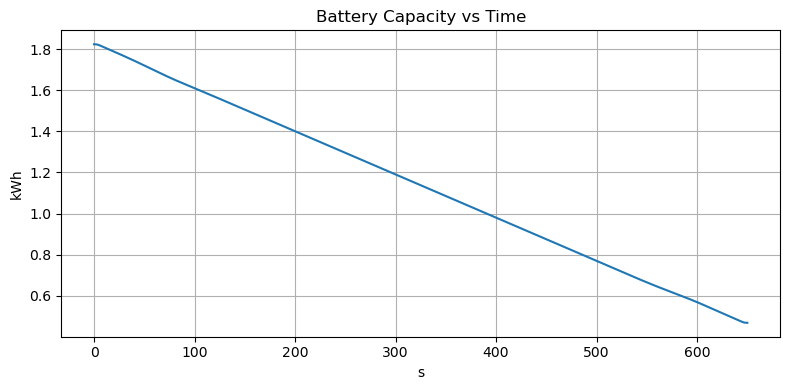

In [6]:

# Battery Capacity vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Battery Capacity vs Time")
plt.plot(drone_power.timesteps, drone_power.energy_remaining * uc.s_to_hrs * uc.mW_to_kW)
plt.grid()
plt.ylabel("kWh")
plt.xlabel("s")
plt.tight_layout()
plt.show()

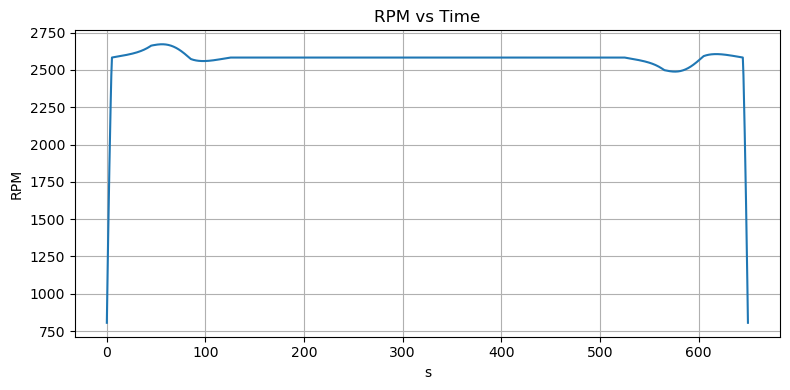

In [7]:

# Throttle vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("RPM vs Time")
plt.plot(drone_power.timesteps, drone_power.rpm)
plt.grid()
plt.ylabel("RPM")
plt.xlabel("s")
plt.tight_layout()
plt.show()


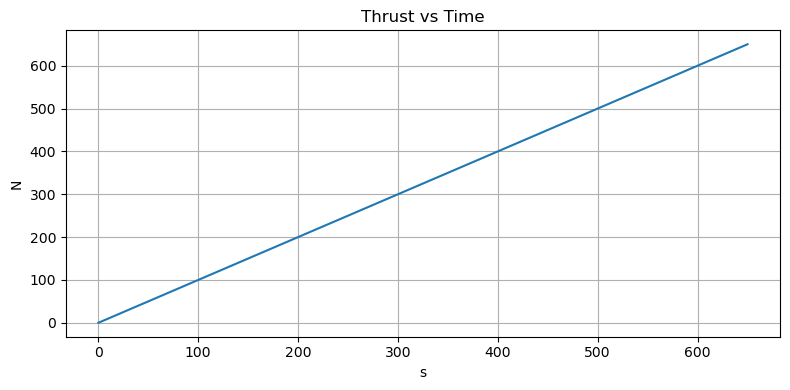

In [8]:
plt.figure(figsize=(8, 4))
plt.title("Thrust vs Time")
plt.plot(time_list, thrust_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

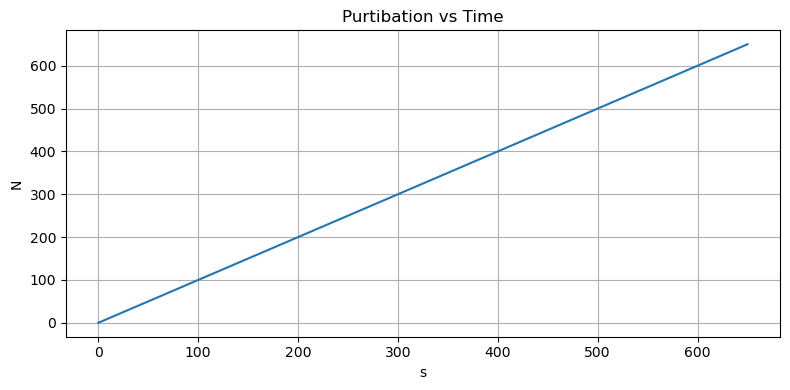

In [9]:
plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list, osc_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

In [10]:

time_list_2 = np.linspace(0, 5, 1000)
osc_list_2 = np.zeros(len(time_list_2))
for i, t in enumerate(time_list_2):
    osc_list_2[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)

plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list_2, osc_list_2)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

NameError: name 'surface_area' is not defined

In [12]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_obj(opt, "arm_thickness", "strut_thickness", 30, design_variables, (0.2, 0.5), (0.2, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

KeyboardInterrupt: 

In [31]:

opt2 = Optimizer()
opt2.independent_properties_calc()
print(opt.mission_profile.duration)
opt2.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt2.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.3,
    "strut_distance": 475,
    "hub_radius": 250,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

res = opt2.run_opt()

x = np.array(res.x)
x_expanded = list(opt2.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt2.test_results(x)

dv_keys = list(opt2.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"mass w/ payload: {res.fun * 1000} kg")

print("OPT_OUTPUT")
opt2.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

640


KeyboardInterrupt: 

In [16]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc

## FEA Model Segment ##
fea_model_seg = opt.fea.beam_system

uav_fea_model_full = fea.DroneFEA(opt.drone_geometry)
uav_fea_model_full.create_drone_nodes()
uav_fea_model_full.create_drone_beams()
uav_fea_model_full.boundary_conditions()
uav_fea_model_full.solve_fea()

fea_model_full = uav_fea_model_full.beam_system


Full 50mm disp:
First 10 Natural Frequencies: [20.314 22.425 24.5   24.5   28.215 28.215 30.779 30.779 31.633 33.274
 33.3   33.3   33.32  33.32  33.32  33.321 33.321 35.092 35.092 38.456
 38.456 39.183 39.183 39.34  61.583 62.717 62.717 65.401 65.401 67.89 ] Hz
Segment 50mm disp:
First 10 Natural Frequencies: [   33.274    41.833    82.201   117.615   141.832   168.69    245.562
   504.221   504.404   504.404   505.294   756.758   912.607  1695.535
  3037.255  3263.456  4019.707  4019.715  6365.534  6410.153  7017.018
 10143.745 10842.669 10865.623 13816.57  14185.215 14446.909 16789.749
 19029.198 20329.777] Hz
Prop Frequency Range: 86.27257621667192-89.0603857765713 Hz


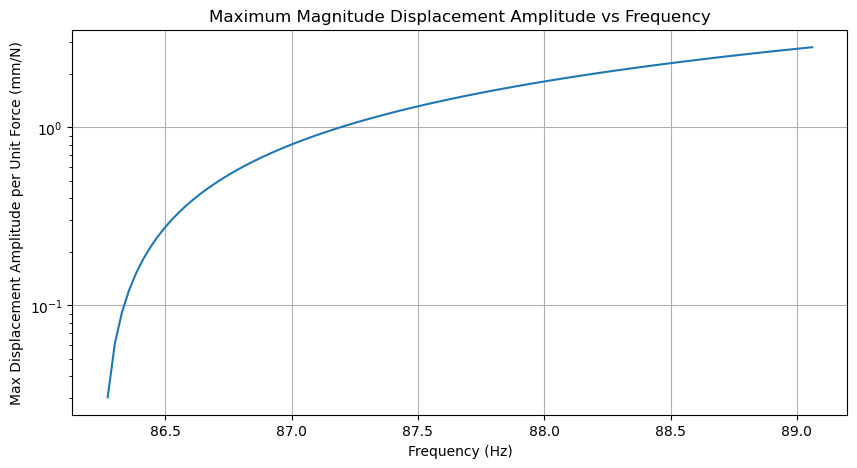

In [18]:
import matplotlib.pyplot as plt

## Freuency Analysis ##
fea_model_seg.solve_natural_frequencies()
fea_model_full.solve_natural_frequencies()

nat_fre_hz = fea_model_seg.natural_frequencies * uc.rad_per_s_to_Hz
full_nat_fre_hz = fea_model_full.natural_frequencies * uc.rad_per_s_to_Hz

print(f"Full 50mm disp:")
print(f"First 10 Natural Frequencies: {full_nat_fre_hz[:30]} Hz")

print("Segment 50mm disp:")
print(f"First 10 Natural Frequencies: {nat_fre_hz[:30]} Hz")


# Max Frequency #

drone_power = opt.drone_power_module
drone_power.freq_trans_calc()
max_freq = np.max(drone_power.frequency)
min_freq = np.min(drone_power.frequency[15:1:-15])
print(f"Prop Frequency Range: {min_freq * uc.rad_per_s_to_Hz}-{max_freq * uc.rad_per_s_to_Hz} Hz")

## Frequency Plotting ##
n_samples = 100
frequency_sample = np.linspace(min_freq, max_freq, n_samples)



max_amps = []
force = opt.parameters["gravity"] * (opt.parameters["payload"] / opt.parameters["blade_num"])
for freq in frequency_sample:
    test_freq_fea = fea_model_full
    test_freq_fea.init_dynamic_forces(freq)
    for i in range(7):
        node = f"outer_node_{i}"
        test_freq_fea.add_dynamic_harmonic_force(np.array([0, 0, 1, 0, 0, 0]), node)
    test_freq_fea.solve_dynamic_harmonic(0,0)
    max_amps.append(max(test_freq_fea.mag_displacements_amplitude))

plt.figure(figsize=(10, 5))
plt.plot(frequency_sample * uc.rad_per_s_to_Hz, max_amps)
plt.title("Maximum Magnitude Displacement Amplitude vs Frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Max Displacement Amplitude per Unit Force (mm/N)")
plt.grid(True)
plt.yscale('log')
plt.show()


In [13]:
print(drone_power.rpm)
#

[ 805.73  1093.123 1363.716 1617.51  1854.503 2074.696 2278.089 2464.682
 2582.973 2583.717 2584.46  2585.203 2585.946 2586.689 2587.433 2588.177
 2588.923 2589.671 2590.421 2591.174 2591.93  2592.691 2593.456 2594.228
 2595.006 2595.792 2596.587 2597.391 2598.206 2599.034 2599.874 2600.73
 2601.601 2602.489 2603.397 2604.324 2605.274 2606.247 2607.246 2608.271
 2609.325 2610.41  2611.527 2612.679 2613.867 2615.094 2616.362 2617.672
 2619.027 2620.43  2621.882 2623.386 2624.945 2626.56  2628.234 2629.971
 2631.771 2633.639 2635.576 2637.585 2639.669 2641.83  2644.072 2646.398
 2648.809 2651.309 2653.901 2656.587 2659.371 2662.255 2663.427 2664.252
 2665.063 2665.855 2666.62  2667.354 2668.05  2668.702 2669.306 2669.855
 2670.346 2670.773 2671.133 2671.42  2671.632 2671.763 2671.812 2671.773
 2671.645 2671.425 2671.109 2670.695 2670.182 2669.566 2668.847 2668.022
 2667.09  2666.05  2664.901 2663.642 2662.273 2660.792 2659.201 2657.498
 2655.685 2653.761 2651.727 2649.584 2647.334 2644.9

In [14]:
## Energy Analysis ## 


drone_power = opt.drone_power_module

print(f"Total Energy Capacity: {drone_power.milliwatt_hour_capacity*10**-6} kWh")
print(f"Final Energy Remaining: {drone_power.energy_remaining[-1] * uc.s_to_hrs*10**-6} kWh")
print(f"% Energy Remaining: {drone_power.energy_remaining[-1] * uc.s_to_hrs*10**-6} %")
print(f"Mission Duration: {opt.mission_profile.duration} s")
print(f"Min Throttle: {np.min(drone_power.percent_throttle[10:-10]) * 100:.2f} %")
print(f"Average Throttle: {np.mean(drone_power.percent_throttle) * 100:.2f} %")
print(f"Peak Throttle: {np.max(drone_power.percent_throttle) * 100:.2f} %")

print(f"Min RPM: {np.min(drone_power.rpm[10:-10]):.2f}")
print(f"Average RPM: {np.mean(drone_power.rpm):.2f}")
print(f"Peak RPM: {np.max(drone_power.rpm):.2f}")

# 176.4 N = 9.8m/s^2
# 1,602,677
# power_milliwatts = 37,194,316
# 37,194,316
print("max_power:",drone_power.thrust_to_power(176.4*8))
# https://uav-en.tmotor.com/2018/Polymer_Folding_0815/183.html


Total Energy Capacity: 1.8239999999999998 kWh
Final Energy Remaining: 0.46860844016036485 kWh
% Energy Remaining: 0.46860844016036485 %
Mission Duration: 640 s
Min Throttle: 41.94 %
Average Throttle: 46.87 %
Peak Throttle: 53.06 %
Min RPM: 2488.60
Average RPM: 2568.26
Peak RPM: 2671.81
max_power: 36610914.782569595


In [17]:
# Displacement / Stress

fea_seg = opt.fea.beam_system

max_disp = print(f"max disp: {np.max(fea_seg.mag_displacements)}")
max_disp = print(f"max disp: {fea_seg.beams[fea_seg.select_element("outer_beam")].bending_stresses_0} Mpa")

max disp: 9.999999999986853
max disp: 18.290237598983218 Mpa


In [9]:
## MASS ##
dv = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": x_expanded[3],
    "strut_distance": x_expanded[4],
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
print(f"Initial Guess")
print(f"Frame mass: {opt.mass(opt.design_variables_initial_guess) * 1000} kg")
print(f"Frame mass moment of inertia: {opt.moment(opt.design_variables_initial_guess) * 10**-3}  kg*m^2")
print(f"Objective: {opt.objective(opt.design_variables_initial_guess)}")
print("Optimized")
print(f"Frame mass: {opt.mass(dv) * 1000} kg")
print(f"Frame mass moment of inertia: {opt.moment(dv) * 10**-3} kg*m^2")
print(f"Objective: {opt.objective(dv)}")

print(f"mass_contribution:{ opt.mass(dv) * opt.constraints_constants["weight_mass"] / opt.constraints_constants["scaling_mass"]}")
print(f"mass_moment_contribution:{ opt.moment(dv) * opt.constraints_constants["weight_mass_moment"] /  opt.constraints_constants["scaling_mass_moment"]}")

Initial Guess
Frame mass: 6.399426050148722 kg
Frame mass moment of inertia: 1.2300833561577602  kg*m^2
Objective: 0.40955375382664977
Optimized
Frame mass: 7.781018485116816 kg
Frame mass moment of inertia: 0.7598080003804574 kg*m^2
Objective: 0.2526929617205142
mass_contribution:-0.0005763717396382826
mass_moment_contribution:0.25326933346015246


In [28]:
drone_geometry = opt.drone_geometry
print(f"surface area projected: {drone_geometry.projected_surface_area} mm^2")

surface area projected: 1726272.2020683186 mm^2


In [40]:
## Transient Results ##

print("Transient")
fea_seg = opt.fea.beam_system
for i in range(len(fea_seg.beams)):
    print(np.max(np.array([fea_seg.beams[i].bending_stresses_0_ts, fea_seg.beams[i].bending_stresses_1_ts])))

# 133 MPa
# Strength
print(f"Displacements: ")
for z in fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1]:
    print(f"{z}, ", end='')

print(f"\nMax Deflection: {np.max(fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1])}")

print(f"\nMin Deflection: {np.min(fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1])}")

Transient
47.322555921590244
39.0122732880158
35.32268423954959
31.858886267733226
28.218190355773203
41.80796590862035
43.98128671173732
11.219735774468647
11.219735774468699
Displacements: 
0.0, 1.6754139391742444, 3.3908104245670736, 5.017376762689931, 6.733619148991656, 8.491473166029884, 10.146948019587636, 11.886876653586883, 12.804886413676673, 12.807012262628685, 12.837695612770439, 12.91653929328506, 13.058221857764774, 13.048259958343714, 12.853271463820192, 13.031292777318269, 12.96776857765481, 13.046920592339106, 12.88360905612631, 13.055259624566157, 13.153069287527282, 13.15662035919161, 13.12201479739982, 12.925855694828362, 13.195160940886709, 12.985799172304576, 12.98354116717755, 13.119613311081336, 13.121982762254278, 13.240014946045694, 13.101033516907622, 13.320597500092626, 13.303358443528499, 13.308746959555393, 13.398320251006066, 13.437546704626481, 13.299878885872337, 13.476948046670673, 13.31649418611225, 13.475806536724658, 13.643019877673199, 13.4939762065

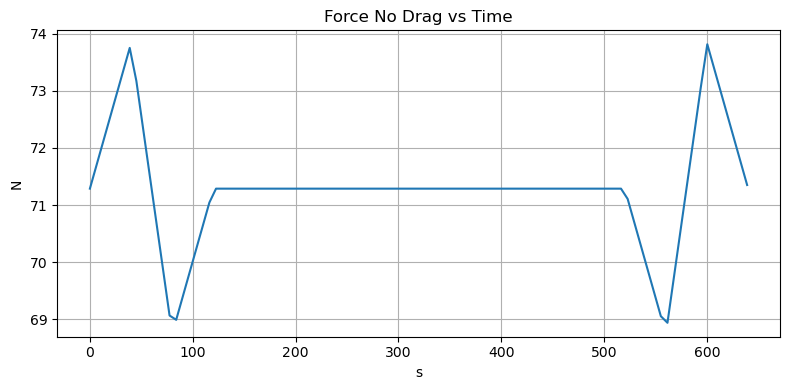

In [45]:
# force
plt.figure(figsize=(8, 4))
plt.title("Force No Drag vs Time")
t_range = np.linspace(0, opt.mission_profile.duration-1, 100)
force = np.zeros(len(t_range))
for i, t in enumerate(t_range):
    p,v,a = opt.mission_profile.time_solve(t)
    force[i] =  (a[1] + opt.parameters["gravity"]) * opt.drone_mass / opt.parameters["blade_num"]

plt.plot(t_range, force)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

In [1]:
# Drag
plt.figure(figsize=(8, 4))
plt.title("Drag vs Time")
t_range = np.linspace(0, opt.mission_profile.duration-1, 100)
drag = np.zeros(len(t_range))
for i, t in enumerate(t_range):
    p,v,a = opt.mission_profile.time_solve(t)
    drag[i] = (np.sign(v[1]) * (v[1] ** 2) * opt.drone_geometry.projected_surface_area * opt.parameters["air_density"] * opt.parameters["drag_coeff"]) / 8

plt.plot(t_range, drag)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()



NameError: name 'plt' is not defined

In [58]:
import math
hub_side_length = 2 * 480 * math.tan(math.pi / opt.parameters["blade_num"])
print(hub_side_length)

397.64501987817124


The user wants a 3D stick model plot of the UAV geometry with the ability to label specific nodes. I will create a function that iterates through the nodes and beams of the `BeamSystem` within the `DroneFEA` object, plotting the segments and optionally labeling nodes based on a provided list of indices or labels.

### Task Summary and Clarification
1.  **Task**: Develop a function `plot_drone_with_labels` to visualize the UAV as a 3D stick model.
2.  **Functionality**:
    *   Plot all beams as lines in 3D space.
    *   Accept a list of node indices or a boolean flag to label specific nodes.
    *   Display node labels at their respective 3D coordinates.
3.  **Tools**: Use `matplotlib.pyplot` and `mpl_toolkits.mplot3d`.
4.  **Integration**: The function will take `opt.fea` (a `DroneFEA` instance) as input, similar to existing visualization functions.

### New Cell: Function Definition for Labeled 3D Stick Model



In [65]:
import matplotlib.pyplot as plt
import numpy as np


def plot_drone_with_labels(drone_fea, labeled_node_indices=None, node_titles=None, title="UAV 3D Beam Model"):
    """
    Plots a 3D stick model of the UAV with optional node labeling.
    
    :param drone_fea: DroneFEA object containing the beam system.
    :param labeled_node_indices: List of node indices (int) to label on the plot. 
                                 If None, no nodes are labeled.
    :param node_titles: Optional list of strings to use as titles for the labeled nodes.
                        Must be the same length as labeled_node_indices.
    :param title: Title of the plot.
    """
    fig = plt.figure(figsize=(25, 15))
    ax = fig.add_subplot(111, projection='3d')

    beam_system = drone_fea.beam_system

    # Plot Beams
    for beam in beam_system.beams:
        start = beam.start_node.location
        end = beam.end_node.location
        ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], color='b', linewidth=1.5)

    # Plot Nodes and Labels
    for i, node in enumerate(beam_system.nodes):
        loc = node.location
        # Increase scatter size 's' to make points more discernable
        ax.scatter(loc[0], loc[1], loc[2], color='darkred', s=20)

        # Add labels for selected nodes
        if labeled_node_indices is not None and i in labeled_node_indices:
            label_idx = labeled_node_indices.index(i)
            if node_titles is not None and label_idx < len(node_titles):
                label_text = node_titles[label_idx]
            else:
                label_text = f'Node {i}'

            ax.text(loc[0], loc[1], loc[2], label_text, size=11, zorder=10, color='darkred', weight='bold')

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Z (mm)')

    # Equalize axis scaling
    max_range = np.array([
        ax.get_xlim()[1] - ax.get_xlim()[0],
        ax.get_ylim()[1] - ax.get_ylim()[0],
        ax.get_zlim()[1] - ax.get_zlim()[0]
    ]).max() / 2.0

    mid_x = (ax.get_xlim()[1] + ax.get_xlim()[0]) * 0.5
    mid_y = (ax.get_ylim()[1] + ax.get_ylim()[0]) * 0.5
    mid_z = (ax.get_zlim()[1] + ax.get_zlim()[0]) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    # Reduced y-axis range (cut some) while maintaining mid-point. 
    # Note: In 3D plots, set_box_aspect or manual limits control visual aspect.
    # To strictly 'cut' without warping, we reduce the range relative to max_range.
    ax.set_ylim(mid_y - max_range * 0.3, mid_y + max_range * 0.3)
    ax.set_zlim(mid_z - max_range * 0.2, mid_z + max_range * 0.2)

    # Ensure aspect ratio is consistent
    ax.set_box_aspect((1, 0.3, 0.2))

    plt.show()


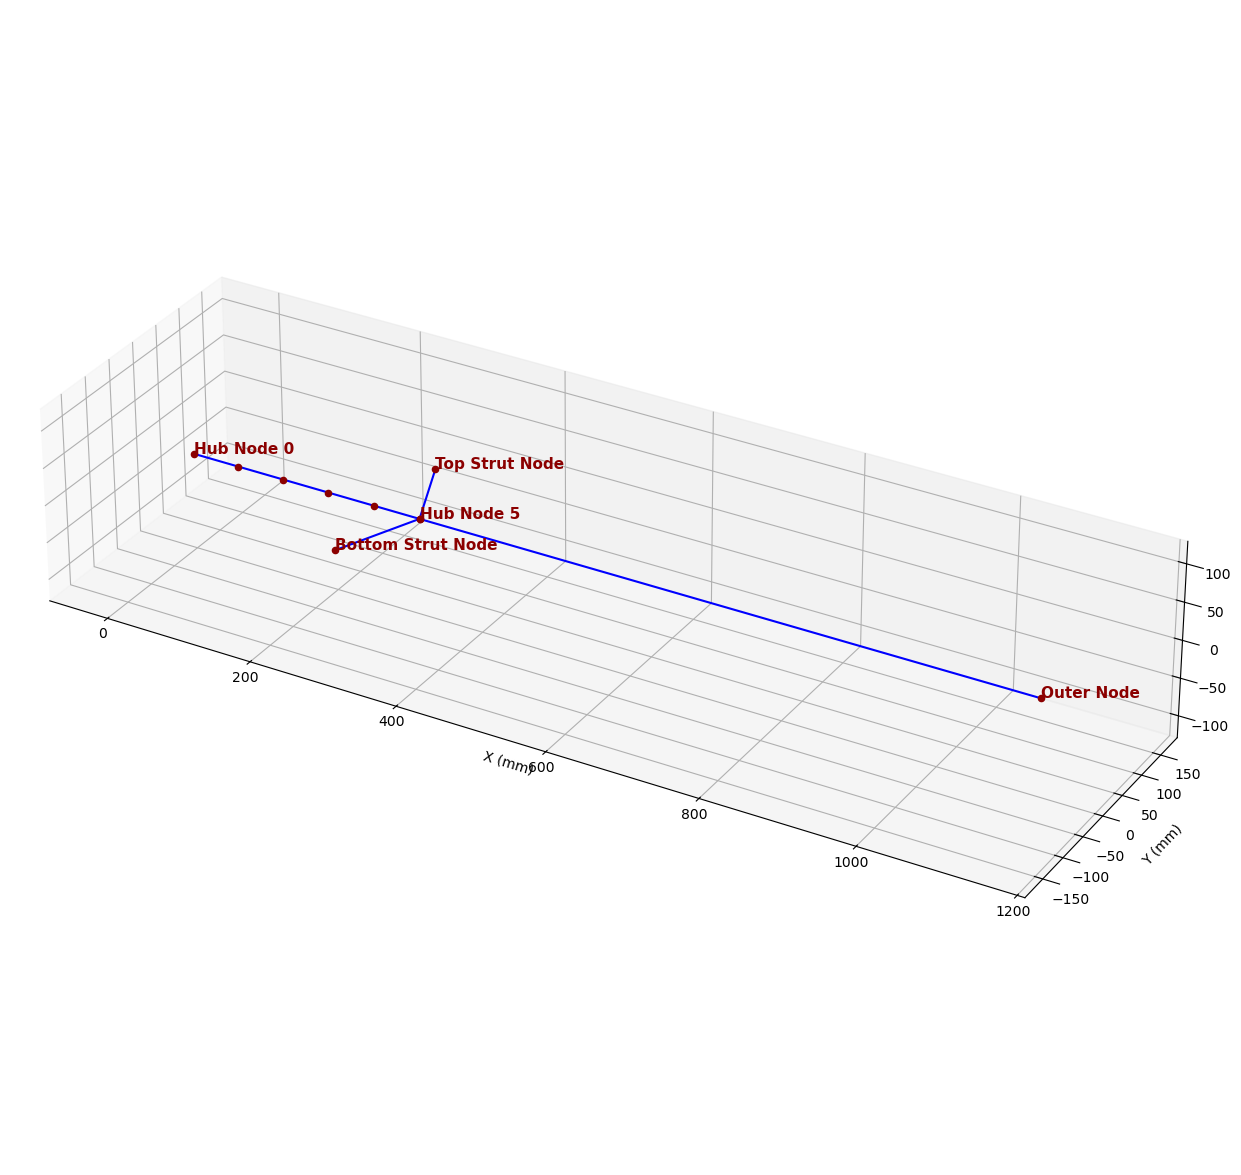

In [66]:

b = opt.fea.beam_system
nodes_to_label = [
    b.select_node("outer_node"), b.select_node("hub_node_0"), b.select_node("hub_node_5"), b.select_node("strut_node_top"), b.select_node("strut_node_bottom")]
nodes_to_titles = ["Outer Node", "Hub Node 0", "Hub Node 5", "Top Strut Node", "Bottom Strut Node"]
plot_drone_with_labels(opt.fea, node_titles=nodes_to_titles, labeled_node_indices=nodes_to_label)
